<a href="https://colab.research.google.com/github/walnutta/404_project/blob/main/404groupprj_final_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import sklearn
import re


In [2]:
from google.colab import drive
from sklearn.model_selection import train_test_split

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/404data/"

df = pd.read_csv(DRIVE_PATH + "train-balanced-sarcasm.csv", low_memory=False)

# sample 310k total, 300k train + 10k test
df_sampled = df.sample(n=810000, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(df_sampled, test_size=10000,
    random_state=42, stratify=df_sampled["label"]
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Train balance: {train_df.label.value_counts().to_dict()}")
print(f"Test balance:  {test_df.label.value_counts().to_dict()}")

Mounted at /content/drive
Train: (800000, 10)
Test:  (10000, 10)
Train balance: {1: 400082, 0: 399918}
Test balance:  {1: 5001, 0: 4999}


In [3]:
reddit_test_df = pd.read_json(
    "https://raw.githubusercontent.com/EducationalTestingService/sarcasm/master/reddit/sarcasm_detection_shared_task_reddit_testing.jsonl",
    lines=True
)

test_df_reddit = reddit_test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"ETS Reddit test: {test_df_reddit.shape}")
print(f"Label balance: {test_df_reddit.label.value_counts().to_dict()}")

ETS Reddit test: (1800, 4)
Label balance: {'SARCASM': 900, 'NOT_SARCASM': 900}


In [4]:
train_df.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,1,What's not to love about corporate welfare?,ENkats,Minneapolis,7,7,0,2016-01,2016-01-27 16:13:40,"This isn't such a tough question, really. It's..."
1,0,"I would *love* for CK2 to push into 1500 or, m...",ElvishisnotTengwar,CrusaderKings,1,1,0,2016-04,2016-04-02 18:36:14,seeing as people made the game work with TES o...
2,0,Money.,commencedownvotes,AskReddit,2,2,0,2014-12,2014-12-27 12:18:17,0 What is your method of attracting girls/maki...
3,1,Why would anyone get a 390 when they can get a...,giotariz,pcmasterrace,4,4,0,2016-03,2016-03-09 07:33:30,*-Insert obligatory comment about how 390 is b...
4,1,You obviously are not thinking of the children...,captmorgan50,todayilearned,17,17,0,2014-02,2014-02-12 17:20:24,They're not being dumb. They know exactly what...


In [5]:
train_df.columns

Index(['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs',
       'date', 'created_utc', 'parent_comment'],
      dtype='object')

In [4]:
def count_sarcastic_emojis(text):
  sarcastic_emojis = {"🙄", "😒", "😏", "🤦", "💀", "😐", "🫠", "😑", "👏", "🤷"}
  return sum(1 for char in text if char in sarcastic_emojis)

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s*/s\b', '', text)  # remove /s sarcasm tag
    text = re.sub(r'@USER', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def process_row(row):
  # Kaggle uses comment, ETS uses response
  raw = str(row["comment"]) if "comment" in row.index else str(row["response"])

  reply_depth    = len(re.findall(r"@USER", raw))
  exclaim_count  = raw.count("!")
  question_count = raw.count("?")

  cleaned_response = clean_text(raw)

  # Kaggle uses parent_comment (string), ETS uses context (list)
  if "context" in row.index and isinstance(row["context"], list):
    context_str = clean_text(" ".join([str(c) for c in row["context"]]))
  elif "parent_comment" in row.index and pd.notna(row["parent_comment"]):
    context_str = clean_text(str(row["parent_comment"]))
  else:
    context_str = ""

  full_text = cleaned_response + " [CONTEXT] " + context_str

  # Kaggle label is 0/1, ETS label is SARCASM/NOT_SARCASM
  raw_label = row["label"]
  if isinstance(raw_label, str):
    label = 1 if raw_label == "SARCASM" else 0
  else:
    label = int(raw_label)

  return pd.Series({
    "clean_response": cleaned_response,
    "full_text":      full_text,
    "reply_depth":    reply_depth,
    "exclaim_count":  exclaim_count,
    "question_count": question_count,
    "label":          label
  })

train_clean = train_df.apply(process_row, axis=1)
test_clean = test_df.apply(process_row, axis=1)
test_clean_ets = test_df_reddit.apply(process_row, axis=1)

train_clean.head()


,clean_response,full_text,reply_depth,exclaim_count,question_count,label
0,What's not to love about corporate welfare?,What's not to love about corporate welfare? [C...,0,0,1,1
1,"I would *love* for CK2 to push into 1500 or, m...","I would *love* for CK2 to push into 1500 or, m...",0,0,0,0
2,Money.,Money. [CONTEXT] 0 What is your method of attr...,0,0,0,0
3,Why would anyone get a 390 when they can get a...,Why would anyone get a 390 when they can get a...,0,0,1,1
4,You obviously are not thinking of the children...,You obviously are not thinking of the children...,0,0,0,1


# Logistic Regression

              precision    recall  f1-score   support

 Not Sarcasm       0.69      0.72      0.71      4999
     Sarcasm       0.71      0.68      0.69      5001

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



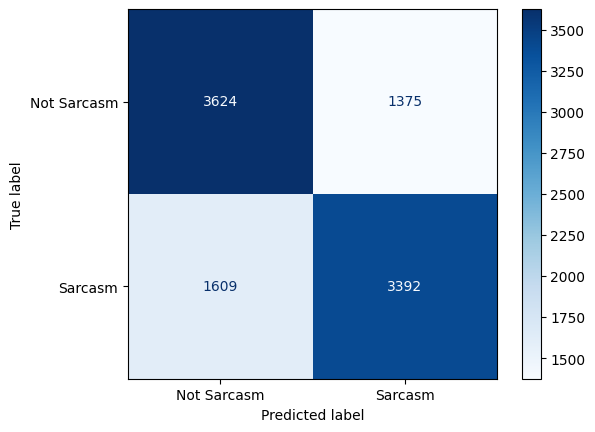

In [12]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(train_clean["full_text"])
X_test_tfidf  = vectorizer.transform(test_clean["full_text"])

feature_cols = ['reply_depth', 'exclaim_count', 'question_count']

extra_train = train_clean[feature_cols].values
extra_test  = test_clean[feature_cols].values

X_train = hstack([X_train_tfidf, extra_train])
X_test  = hstack([X_test_tfidf,  extra_test])
y_train = train_clean["label"]
y_test  = test_clean["label"]

model = LogisticRegression(max_iter=5000, solver="liblinear", C=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Not Sarcasm", "Sarcasm"]))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

#### Test on hand-annotated data

LR on ETS (cross-domain):
              precision    recall  f1-score   support

 Not Sarcasm       0.64      0.54      0.58       900
     Sarcasm       0.60      0.69      0.64       900

    accuracy                           0.62      1800
   macro avg       0.62      0.62      0.61      1800
weighted avg       0.62      0.62      0.61      1800



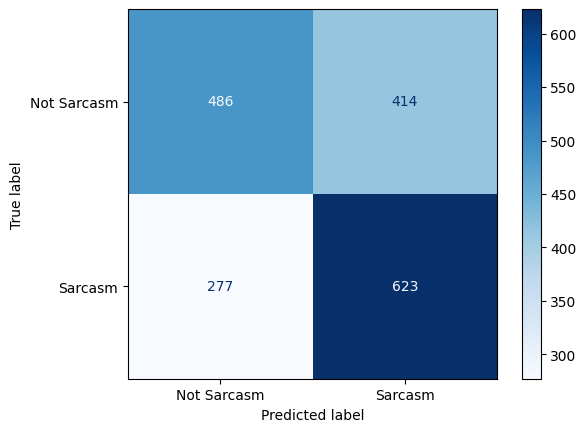

In [14]:
# transform ETS through the already-fitted vectorizer
X_test_tfidf_ets = vectorizer.transform(test_clean_ets["full_text"])

feature_cols = ['reply_depth', 'exclaim_count', 'question_count']
extra_test_ets = test_clean_ets[feature_cols].values

X_test_ets = hstack([X_test_tfidf_ets, extra_test_ets])
y_test_ets = test_clean_ets["label"]

y_pred_ets = model.predict(X_test_ets)

print("LR on ETS (cross-domain):")
print(classification_report(y_test_ets, y_pred_ets, target_names=["Not Sarcasm", "Sarcasm"]))
cm = confusion_matrix(y_test_ets, y_pred_ets)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

# RNN

In [5]:
import tensorflow as tf
from tensorflow import keras
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from keras.regularizers import l2
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D

In [16]:
!wget https://nlp.stanford.edu/data/glove.2024.dolma.300d.zip
!unzip glove.2024.dolma.300d.zip

--2026-04-16 00:24:22--  https://nlp.stanford.edu/data/glove.2024.dolma.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.2024.dolma.300d.zip [following]
--2026-04-16 00:24:23--  https://downloads.cs.stanford.edu/nlp/data/glove.2024.dolma.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1673618188 (1.6G) [application/zip]
Saving to: ‘glove.2024.dolma.300d.zip’

glove.2024.dolma.30 100%[===================>]   1.56G  5.01MB/s    in 5m 17s  

2026-04-16 00:29:41 (5.04 MB/s) - ‘glove.2024.dolma.300d.zip’ saved [1673618188/1673618188]

Archive:  glove.2024.dolma.300d.zip
  inf

In [17]:
!ls *.txt

dolma_300_2024_1.2M.100_combined.txt


In [18]:
MAX_VOCAB = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean["full_text"])

X_train_seq = tokenizer.texts_to_sequences(train_clean["full_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_clean["full_text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_clean["label"].values
y_test  = test_clean["label"].values

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

glove_embeddings = {}
with open('dolma_300_2024_1.2M.100_combined.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} word vectors")

EMBEDDING_DIM = 300
embedding_matrix = np.zeros((MAX_VOCAB, EMBEDDING_DIM))
for word, idx in tokenizer.word_index.items():
    if idx < MAX_VOCAB:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

model = Sequential([
    Embedding(MAX_VOCAB, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(X_train_pad, y_train, epochs=40, batch_size=256,
                    validation_data=(X_test_pad, y_test))
model.summary()

Train shape: (800000, 200)
Test shape:  (10000, 200)
Loaded 1200001 word vectors
Embedding matrix shape: (20000, 300)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - accuracy: 0.5587 - loss: 1.3566 - val_accuracy: 0.6207 - val_loss: 1.1739
Epoch 2/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6231 - loss: 1.0390 - val_accuracy: 0.6338 - val_loss: 0.9167
Epoch 3/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6456 - loss: 0.8345 - val_accuracy: 0.6600 - val_loss: 0.7569
Epoch 4/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6648 - loss: 0.7122 - val_accuracy: 0.6703 - val_loss: 0.6684
Epoch 5/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6761 - loss: 0.6479 - val_accuracy: 0.6810 - val_loss: 0.6245
Epoch 6/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6829 - loss: 0.6175 - val_accuracy: 0.6890 - val_loss: 0.6036
Epoch 7/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6886 - loss: 0.6027 - val_accuracy: 0.6906 - val_loss: 0.5949
Epoch 8/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6934 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (256, 200, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (256, 200, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (256, 128)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (256, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (256, 64)              │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (256, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (256, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,585,605 (70.90 MB)

 Trainable params: 6,195,201 (23.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,390,404 (47.27 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

 Not Sarcasm       0.71      0.75      0.73      4999
     Sarcasm       0.73      0.69      0.71      5001

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



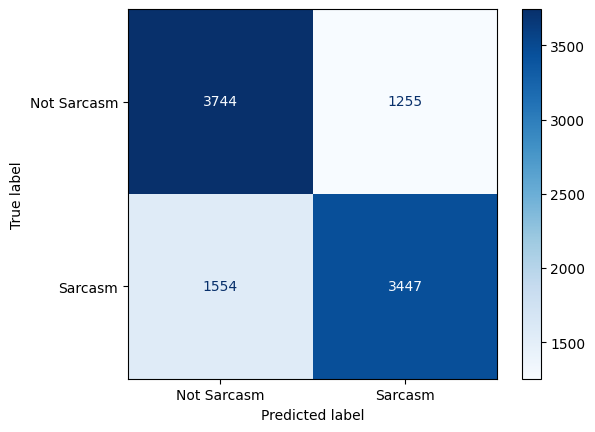

In [19]:
y_pred_prob = model.predict(X_test_pad)
y_pred_rnn = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred_rnn, target_names=["Not Sarcasm", "Sarcasm"]))

cm = confusion_matrix(y_test, y_pred_rnn)
ConfusionMatrixDisplay(cm, display_labels=["Not Sarcasm", "Sarcasm"]).plot(cmap="Blues")

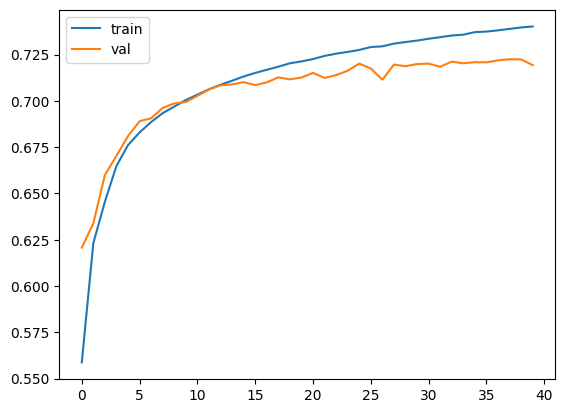

In [20]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

#### Test on hand-annotated Data

In [21]:
X_test_seq  = tokenizer.texts_to_sequences(test_clean_ets["full_text"])
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")
y_test  = test_clean_ets["label"].values

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

model = Sequential([
    Embedding(MAX_VOCAB, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(X_train_pad, y_train, epochs=40, batch_size=256,
                    validation_data=(X_test_pad, y_test))
model.summary()

Train shape: (800000, 200)
Test shape:  (1800, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - accuracy: 0.5573 - loss: 1.3453 - val_accuracy: 0.6078 - val_loss: 1.1670
Epoch 2/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6181 - loss: 1.0356 - val_accuracy: 0.6239 - val_loss: 0.9316
Epoch 3/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6339 - loss: 0.8463 - val_accuracy: 0.6211 - val_loss: 0.7930
Epoch 4/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6503 - loss: 0.7265 - val_accuracy: 0.6350 - val_loss: 0.7044
Epoch 5/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6666 - loss: 0.6582 - val_accuracy: 0.6433 - val_loss: 0.6634
Epoch 6/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6769 - loss: 0.6252 - val_accuracy: 0.6533 - val_loss: 0.6442
Epoch 7/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6845 - loss: 0.6085 - val_accuracy: 0.6544 - val_loss: 0.6369
Epoch 8/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.6900 -

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (256, 200, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (256, 200, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (256, 128)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (256, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (256, 64)              │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (256, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (256, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,585,605 (70.90 MB)

 Trainable params: 6,195,201 (23.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,390,404 (47.27 MB)

## Transformer-Based Model (DistilBERT)


Loading and cleaning data...
Sampling 110,000 rows for faster training/testing...
Initializing Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Generating predictions on test set...



Classification Report:
              precision    recall  f1-score   support

 Not Sarcasm       0.74      0.76      0.75      4979
     Sarcasm       0.75      0.73      0.74      5021

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000

Generating Confusion Matrix...


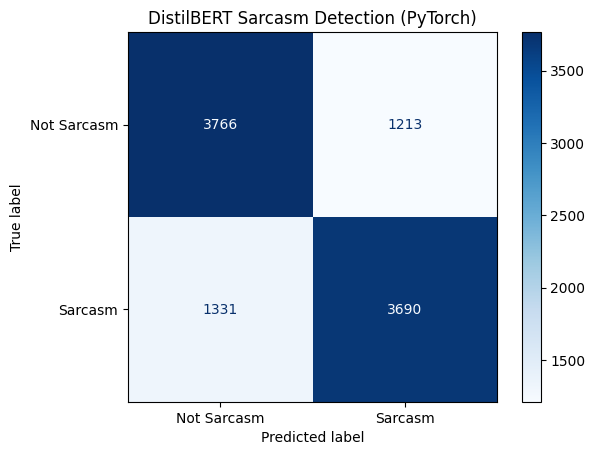

In [23]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# Code done from separate notebook and compiled on the final version here
# Constants and Hyperparameters
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5

# Load and Prepare Data
print("Loading and cleaning data...")

# Added low_memory=False to fix the DtypeWarning
df = pd.read_csv(DRIVE_PATH + "train-balanced-sarcasm.csv", low_memory=False)

# only keep the two columns we care about
if 'comment' in df.columns:
    df = df[['label', 'comment']].copy()
    df = df.rename(columns={'comment': 'full_text'})
else:
    # Fallback just in case
    df = df.iloc[:, 0:2]
    df.columns = ['label', 'full_text']

df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Drop any rows that are missing text or now have a NaN label
df = df.dropna(subset=['label', 'full_text'])

df['full_text'] = df['full_text'].astype(str)
df['label'] = df['label'].astype(int)

print("Sampling 110,000 rows for faster training/testing...")
df_sampled = df.sample(n=110000, random_state=42).reset_index(drop=True)

# Train/Test Split
train_clean, test_clean = train_test_split(df_sampled, test_size=10000, random_state=42)

# Tokenization
print("Initializing Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizing data...")
train_encodings = tokenizer(
    train_clean["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_clean["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

# Create PyTorch Dataset Class
class SarcasmDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Convert encodings to PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item['labels'] = torch.tensor(self.labels[idx]).long()

        return item

    def __len__(self):
        return len(self.labels)

print("Building PyTorch datasets...")
train_dataset = SarcasmDataset(train_encodings, train_clean["label"].values)
test_dataset = SarcasmDataset(test_encodings, test_clean["label"].values)

# Model Initialization&Trainer Setup
print("Loading PyTorch DistilBERT model...")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir='./logs',
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Starting training...")
trainer.train()

# Evaluation & Visualization
print("Generating predictions on test set...")
predictions_output = trainer.predict(test_dataset)
preds = predictions_output.predictions

y_pred = np.argmax(preds, axis=1)

print("\nClassification Report:")
print(classification_report(
    test_clean["label"].values,
    y_pred,
    target_names=["Not Sarcasm", "Sarcasm"]
))

print("Generating Confusion Matrix...")
cm = confusion_matrix(test_clean["label"].values, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Sarcasm", "Sarcasm"]
)
disp.plot(cmap="Blues")
plt.title("DistilBERT Sarcasm Detection (PyTorch)")
plt.show()

#### Test on hand-annotated data

This model was replaced by the one above as the final approach, but the initial f1 score and accuracy was around 71% on the Kaggle data

In [6]:
!pip install transformers datasets -q
!pip install transformers==4.41.2 -q
!pip install -q tensorflow==2.19.0 protobuf==5.29.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 24.3 MB/s eta 0:00:00


In [7]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from transformers.optimization_tf import create_optimizer

In [8]:
# Constants for DistilBERT
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 1e-5

In [9]:
# Loading tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
test_encodings = tokenizer(
    test_clean_ets["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)
# Format the testing data as a TensorFlow dataset
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), test_clean_ets["label"].values
)).batch(BATCH_SIZE)

In [11]:
# Loading model
model = TFAutoModelForSequenceClassification.from_pretrained( MODEL_NAME, num_labels=2)
optimizer, schedule = create_optimizer( init_lr=LEARNING_RATE, num_train_steps=1000, num_warmup_steps=100)

# Full Model Compilation
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [12]:
train_sub = train_clean.sample(n=10000, random_state=42).reset_index(drop=True)

train_encodings = tokenizer(
    train_sub["full_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_sub["label"].values
)).shuffle(1000).batch(BATCH_SIZE)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/3


ResourceExhaustedError: Graph execution error:

Detected at node tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/Softmax defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", l

In [ ]:
preds = model.predict(test_dataset).logits
y_pred = np.argmax(preds, axis=1)

print(classification_report(
    test_clean["label"],
    y_pred,
    target_names=["Not Sarcasm", "Sarcasm"]
))

In [ ]:
cm = confusion_matrix(test_clean["label"], y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=["Not Sarcasm", "Sarcasm"]
).plot(cmap="Blues")

plt.show()

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# Analyzing Misclassified Examples

In [14]:
misclassified_indices = np.where(y_test != y_pred)[0]

misclassified_data = []
for idx in misclassified_indices[:10]: # Displaying first 10 misclassified examples
    text = test_clean['full_text'].iloc[idx]
    true_label = 'Sarcasm' if test_clean['label'].iloc[idx] == 1 else 'Not Sarcasm'
    predicted_label = 'Sarcasm' if y_pred[idx] == 1 else 'Not Sarcasm'
    misclassified_data.append({
        'full_text': text,
        'true_label': true_label,
        'predicted_label': predicted_label
    })

misclassified_df = pd.DataFrame(misclassified_data)
display(misclassified_df)

NameError: name 'y_test' is not defined

In [13]:
# separate false positives and false negatives
false_pos_idx = np.where((y_test == 0) & (y_pred == 1))[0]  # predicted sarcastic, actually not
false_neg_idx = np.where((y_test == 1) & (y_pred == 0))[0]  # predicted not sarcastic, actually is

print(f"False Positives (predicted Sarcasm, actually Not): {len(false_pos_idx)}")
print(f"False Negatives (predicted Not Sarcasm, actually is): {len(false_neg_idx)}")
print()

# length analysis
all_lengths = test_clean['full_text'].str.len()
misclassified_lengths = test_clean['full_text'].iloc[misclassified_indices].str.len()
correct_indices = np.where(y_test == y_pred)[0]
correct_lengths = test_clean['full_text'].iloc[correct_indices].str.len()

print(f"Avg length - misclassified: {misclassified_lengths.mean():.1f} chars")
print(f"Avg length - correct:       {correct_lengths.mean():.1f} chars")
print()

# exclamation and question mark analysis
misc_df = test_clean.iloc[misclassified_indices]
correct_df = test_clean.iloc[correct_indices]

print(f"Avg exclaim_count - misclassified: {misc_df['exclaim_count'].mean():.2f}")
print(f"Avg exclaim_count - correct:       {correct_df['exclaim_count'].mean():.2f}")
print(f"Avg question_count - misclassified: {misc_df['question_count'].mean():.2f}")
print(f"Avg question_count - correct:       {correct_df['question_count'].mean():.2f}")
print()

# context presence
misc_has_context = misc_df['full_text'].str.contains(r'\[SEP\]|\[CONTEXT\]').mean()
correct_has_context = correct_df['full_text'].str.contains(r'\[SEP\]|\[CONTEXT\]').mean()
print(f"Has context - misclassified: {misc_has_context:.2%}")
print(f"Has context - correct:       {correct_has_context:.2%}")

NameError: name 'y_test' is not defined

In [ ]:
print("True labels in misclassified data:\n", misclassified_df['true_label'].value_counts())
print("\nPredicted labels in misclassified data:\n", misclassified_df['predicted_label'].value_counts())

In [ ]:
misclassified_df.to_csv('misclassified_entries.csv', index=False)
print("Misclassified entries saved to 'misclassified_entries.csv'")